# Math for ML - Part 3. Basics of probability theory
#### [Math for ML - Part 1. Basics of Linear algebra & analytic geometry](https://www.kaggle.com/code/kupershtein/math-for-ml-part-1-lin-algebra-an-geometry)

#### [Math for ML - Part 2. Basics of calculus (MatAn)](https://www.kaggle.com/code/kupershtein/math-for-ml-part-2-basics-of-calculus-matan)

#### [Math for ML - Part 4. Basics of mathematical statistics](https://www.kaggle.com/code/kupershtein/math-for-ml-part-4-basics-of-math-statistics)

#### **I hope it useful for you! Thanks for upvote!**¶

## Why probability matters in ML

Machine learning is not only about functions and optimization.  
It is also about **uncertainty**.

Probability helps us reason about:

- randomness in data;
- uncertainty in predictions;
- rare events and noisy observations;
- distributions of features and targets;
- model outputs interpreted as probabilities;
- sampling, inference, confidence, and generalization.

Many ML methods are built directly on probability ideas:

- logistic regression;
- Naive Bayes;
- probabilistic graphical models;
- Bayesian methods;
- generative models;
- anomaly detection;
- uncertainty estimation.

<a id=topics-covered></a>
## Topics covered

1. [Random variables](#1-random-variables)  
2. [Basic probability of events](#2-basic-probability-of-events)  
3. [Conditional probability](#3-conditional-probability)  
4. [Bayes' theorem and the basis of Bayesian classification](#4-bayes-theorem-and-the-basis-of-bayesian-classification)  
5. [Discrete and continuous random variables](#5-discrete-and-continuous-random-variables)  
6. [Distribution law of a random variable](#6-distribution-law-of-a-random-variable)  
7. [PMF, PDF, and CDF](#7-pmf-pdf-and-cdf)  
8. [Histogram](#8-histogram)  
9. [Distributions for discrete random variables](#9-distributions-for-discrete-random-variables)  
10. [Distributions for continuous random variables](#10-distributions-for-continuous-random-variables)  
11. [Central Limit Theorem](#11-central-limit-theorem)  
12. [Law of Large Numbers](#12-law-of-large-numbers)  
13. [Skewness and kurtosis](#13-characteristics-of-a-random-variable-skewness-and-kurtosis)  
14. [Data normalization](#14-data-normalization)  
15. [Bootstrapping](#15-bootstrapping)  
16. [Box plot and IQR](#16-box-plot-and-iqr)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(42)

<a id=1-random-variables></a>
# 1. Random Variables

### What is a random variable?

A **random variable** is a numerical quantity whose value depends on the outcome of a random process.

Examples:

- the number of heads in 10 coin flips;
- the number of users clicking an ad in one hour;
- the waiting time until the next customer arrives;
- the height of a randomly selected person.

A random variable is usually denoted by a capital letter such as $X$.

### Why this matters in ML

In machine learning, many important quantities can be modeled as random variables:

- input features;
- labels or targets;
- prediction errors;
- noise in observations;
- model outputs interpreted probabilistically.

### Common mistakes

- Confusing a random variable with one concrete observed value.
- Forgetting that a random variable can represent uncertainty in data generation.

### ML takeaway

A random variable is the starting point for modeling uncertainty in machine learning.

### Quick check

1. What is the difference between a random variable and a single observed value?  
2. Why can a target variable in ML be viewed as random?  
3. Can a random variable describe time or counts, not just measurements?

[Back to Topics](#topics-covered)

In [2]:
n_trials = 10000
coin_flips = rng.integers(0, 2, size=(n_trials, 10))
X = coin_flips.sum(axis=1)

print("First 20 observed values of X:")
print(X[:20])
print("Average number of heads:", X.mean())

First 20 observed values of X:
[4 8 6 5 6 4 4 4 6 5 7 4 7 5 4 6 3 6 2 5]
Average number of heads: 5.0089


<a id=2-basic-probability-of-events></a>
# 2. Basic Probability of Events

### Events and their probabilities

An **event** is a set of outcomes of a random experiment.

If $A$ is an event, its probability is written as

$$
P(A)
$$

and satisfies

$$
0 \le P(A) \le 1
$$

### Basic operations on events

If $A$ and $B$ are events:

- union: $A \cup B$ means “$A$ or $B$ occurs”;
- intersection: $A \cap B$ means “both $A$ and $B$ occur”;
- complement: $A^c$ means “$A$ does not occur”.

Important rules:

$$
P(A^c) = 1 - P(A)
$$

$$
P(A \cup B) = P(A) + P(B) - P(A \cap B)
$$

If $A$ and $B$ are mutually exclusive, then $P(A \cap B)=0$, so

$$
P(A \cup B) = P(A) + P(B)
$$

### Why this matters in ML

These are the building blocks behind:

- classification probabilities;
- event modeling;
- Naive Bayes reasoning;
- false positive / false negative analysis.

### Common mistakes

- Confusing union with intersection.
- Forgetting to subtract overlap in $P(A \cup B)$.

### ML takeaway

Probability rules for events are the base layer under probabilistic classifiers and uncertainty reasoning.

### Quick check

1. What is the difference between $A \cup B$ and $A \cap B$?  
2. When can probabilities be added directly without subtracting overlap?  
3. Why is event probability important in classification?

[Back to Topics](#topics-covered)

In [3]:
x = rng.normal(size=5000)
y = (x + rng.normal(scale=0.8, size=5000) > 0.5).astype(int)

A = x > 0
B = y == 1

pA = A.mean()
pB = B.mean()
p_intersection = np.mean(A & B)
p_union = np.mean(A | B)

print("P(A) =", pA)
print("P(B) =", pB)
print("P(A ∩ B) =", p_intersection)
print("P(A ∪ B) =", p_union)
print("P(A)+P(B)-P(A∩B) =", pA + pB - p_intersection)

P(A) = 0.4942
P(B) = 0.3398
P(A ∩ B) = 0.2918
P(A ∪ B) = 0.5422
P(A)+P(B)-P(A∩B) = 0.5422


<a id=3-conditional-probability></a>
# 3. Conditional Probability

### What is conditional probability?

Conditional probability answers the question:

> What is the probability of event $A$, given that event $B$ has already occurred?

It is written as

$$
P(A \mid B)
$$

and defined by

$$
P(A \mid B) = \frac{P(A \cap B)}{P(B)}, \quad P(B) > 0
$$

### Independence

Two events $A$ and $B$ are independent if

$$
P(A \cap B) = P(A)P(B)
$$

Equivalently, if $P(B)>0$,

$$
P(A \mid B) = P(A)
$$

### Why this matters in ML

Conditional probability is essential in:

- Bayesian classification;
- probabilistic prediction;
- feature-label relationships;
- updating beliefs after observing evidence.

### Common mistakes

- Confusing $P(A \mid B)$ with $P(B \mid A)$.
- Assuming independence without checking whether it is reasonable.

### ML takeaway

Conditional probability is one of the most important ideas in probabilistic machine learning.

### Quick check

1. What does $P(A \mid B)$ mean?  
2. Why is $P(A \mid B)$ generally not the same as $P(B \mid A)$?  
3. What does independence mean in probability terms?

[Back to Topics](#topics-covered)

In [4]:
x = rng.normal(size=5000)
y = (x + rng.normal(scale=0.8, size=5000) > 0.5).astype(int)

A = x > 0
B = y == 1

p_A_given_B = np.mean(A & B) / np.mean(B)
p_B_given_A = np.mean(A & B) / np.mean(A)

print("P(A | B) =", p_A_given_B)
print("P(B | A) =", p_B_given_A)

P(A | B) = 0.8677733257012021
P(B | A) = 0.6071285542651181


<a id=4-bayes-theorem-and-the-basis-of-bayesian-classification></a>
# 4. Bayes' Theorem and the Basis of Bayesian Classification

### Bayes' theorem

Bayes' theorem connects conditional probabilities in two directions:

$$
P(A \mid B) = \frac{P(B \mid A)P(A)}{P(B)}, \quad P(B)>0
$$

### Interpretation

Bayes' theorem updates probability after observing evidence:

- $P(A)$ is the prior probability;
- $P(B \mid A)$ is the likelihood;
- $P(B)$ is the evidence;
- $P(A \mid B)$ is the posterior probability.

### Why this matters in ML

This is the foundation of **Bayesian classification**, including Naive Bayes.

In classification, we often want:

$$
P(C_k \mid x)
$$

the probability of class $C_k$ given observed features $x$.

Bayes' theorem says

$$
P(C_k \mid x) = \frac{P(x \mid C_k)P(C_k)}{P(x)}
$$

In **Naive Bayes**, we simplify the likelihood by assuming conditional independence of features given the class.

### Common mistakes

- Confusing prior and posterior.
- Forgetting that Naive Bayes uses an independence assumption.

### ML takeaway

Bayes' theorem is the bridge between observed evidence and class probabilities.

### Quick check

1. What is the posterior probability in Bayes' theorem?  
2. Why is Bayes' theorem important for classification?  
3. What simplifying assumption does Naive Bayes make?

[Back to Topics](#topics-covered)

In [5]:
P_C1 = 0.4
P_C0 = 0.6
P_x_given_C1 = 0.8
P_x_given_C0 = 0.3

P_x = P_x_given_C1 * P_C1 + P_x_given_C0 * P_C0

P_C1_given_x = (P_x_given_C1 * P_C1) / P_x
P_C0_given_x = (P_x_given_C0 * P_C0) / P_x

print("P(C=1 | x) =", P_C1_given_x)
print("P(C=0 | x) =", P_C0_given_x)
print("Sum =", P_C1_given_x + P_C0_given_x)

P(C=1 | x) = 0.6400000000000001
P(C=0 | x) = 0.36
Sum = 1.0


[Back to Topics](#topics-covered)

<a id=5-discrete-and-continuous-random-variables></a>
# 5. Discrete and Continuous Random Variables

### Discrete random variable

A **discrete random variable** takes values from a finite or countable set.

### Continuous random variable

A **continuous random variable** can take any value in an interval.

### Why this matters in ML

Different types of random variables require different mathematical tools:

- discrete variables use probability masses;
- continuous variables use densities;
- many models assume specific variable types.

### Common mistakes

- Treating discrete and continuous variables the same way mathematically.
- Thinking a continuous variable can assign nonzero probability to a single exact point.

### ML takeaway

Whether a variable is discrete or continuous determines how we model its distribution.

### Quick check

1. Is the number of fraud events in a day discrete or continuous?  
2. Is customer waiting time discrete or continuous?  
3. Why do discrete and continuous variables need different probability functions?

[Back to Topics](#topics-covered)

In [6]:
discrete_sample = rng.poisson(lam=3.0, size=20)
continuous_sample = rng.normal(loc=0, scale=1, size=20)

print("Discrete sample:", discrete_sample)
print("Continuous sample:", np.round(continuous_sample, 3))

Discrete sample: [3 0 3 3 3 1 5 3 2 7 3 4 3 2 5 2 2 4 2 1]
Continuous sample: [ 2.388 -0.87  -0.156 -0.167 -0.496 -0.432  1.403  0.099  2.489 -0.406
  1.506  1.759 -0.083  0.447  0.883 -0.557  1.664 -0.811 -0.521 -0.51 ]


<a id=6-distribution-law-of-a-random-variable></a>
# 6. Distribution Law of a Random Variable

### What is a distribution law?

The **distribution law** of a random variable describes how probabilities are assigned to possible values.

### Why this matters in ML

Understanding a variable’s distribution helps with:

- choosing appropriate models;
- interpreting uncertainty;
- detecting unusual behavior;
- evaluating assumptions such as normality.

### Common mistakes

- Thinking the distribution is only a graph rather than a full probabilistic description.
- Assuming every variable is approximately normal.

### ML takeaway

A distribution law tells us how uncertainty is structured, not just that uncertainty exists.

### Quick check

1. What does a distribution law describe?  
2. Why is it useful to know the distribution of a feature?  
3. Can two variables have the same mean but different distributions?

[Back to Topics](#topics-covered)

# 7. PMF, PDF, and CDF

### PMF: Probability Mass Function

For a discrete random variable $X$, the **PMF** is

$$
P(X = x)
$$

### PDF: Probability Density Function

For a continuous random variable $X$, the **PDF** is usually denoted by

$$
f(x)
$$

and probabilities are obtained by integrating:

$$
P(a \le X \le b) = \int_a^b f(x)\,dx
$$

### CDF: Cumulative Distribution Function

$$
F(x) = P(X \le x)
$$

### Why this matters in ML

These functions help us interpret uncertainty, compare distributions, and compute event probabilities.

### Common mistakes

- Thinking the PDF value itself is a probability.
- Confusing PMF and CDF.

### ML takeaway

PMF, PDF, and CDF are three fundamental ways to describe distributions.

### Quick check

1. What is the difference between PMF and PDF?  
2. What does the CDF represent?  
3. Why is the PDF not itself a probability?

[Back to Topics](#topics-covered)

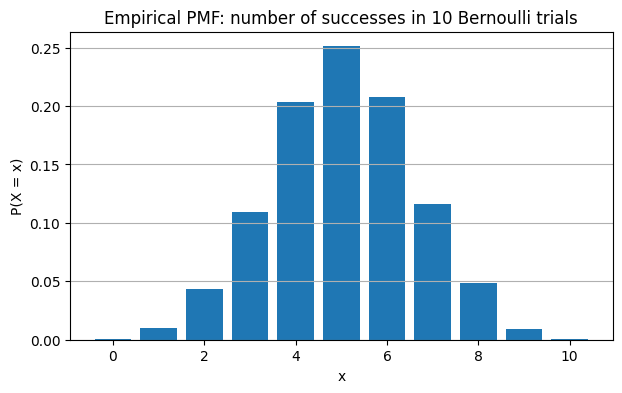

In [7]:
Y = rng.binomial(n=10, p=0.5, size=10000)
values, counts = np.unique(Y, return_counts=True)
pmf_empirical = counts / counts.sum()

plt.figure(figsize=(7, 4))
plt.bar(values, pmf_empirical)
plt.title("Empirical PMF: number of successes in 10 Bernoulli trials")
plt.xlabel("x")
plt.ylabel("P(X = x)")
plt.grid(True, axis="y")
plt.show()

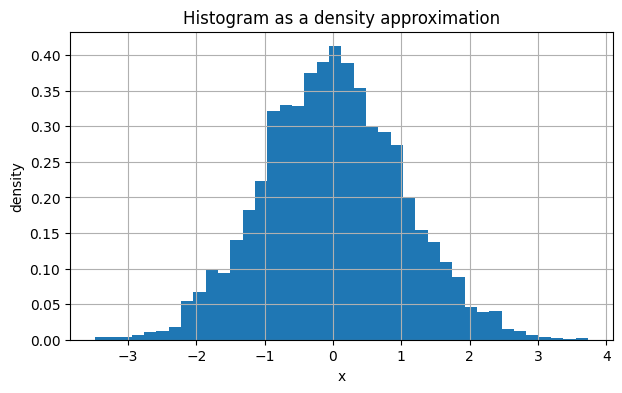

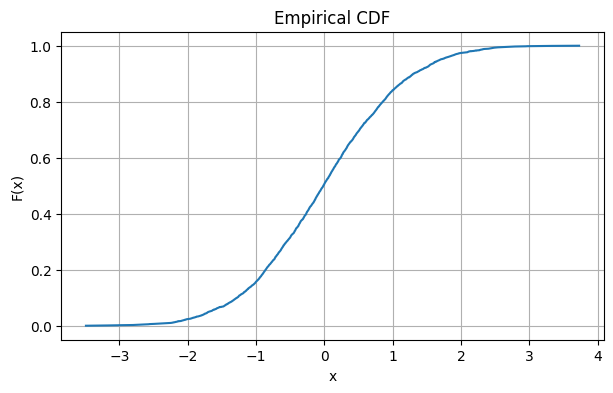

In [8]:
sample = rng.normal(loc=0, scale=1, size=5000)
sorted_sample = np.sort(sample)
cdf_vals = np.arange(1, len(sorted_sample) + 1) / len(sorted_sample)

plt.figure(figsize=(7, 4))
plt.hist(sample, bins=40, density=True)
plt.title("Histogram as a density approximation")
plt.xlabel("x")
plt.ylabel("density")
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(sorted_sample, cdf_vals)
plt.title("Empirical CDF")
plt.xlabel("x")
plt.ylabel("F(x)")
plt.grid(True)
plt.show()

<a id=8-histogram></a>
# 8. Histogram

### What is a histogram?

A **histogram** is a visual summary of data distribution.

### Why this matters in ML

Histograms are useful for:

- inspecting feature distributions;
- detecting skewness;
- spotting multimodality;
- identifying outliers.

### Common mistakes

- Interpreting histogram shape without considering bin size.
- Confusing raw counts with density.

### ML takeaway

A histogram is one of the fastest ways to understand the shape of data before modeling.

### Quick check

1. What does a histogram help us visualize?  
2. Why does bin width matter?  
3. Can a histogram suggest that a transformation may help preprocessing?

[Back to Topics](#topics-covered)

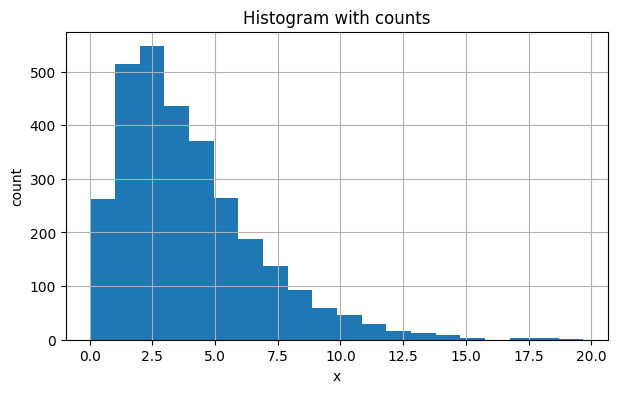

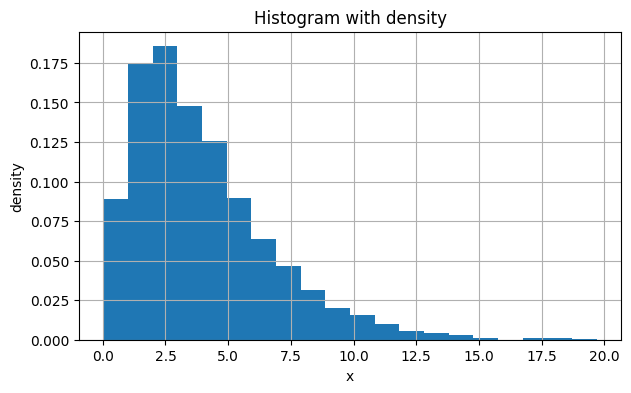

In [9]:
data = rng.gamma(shape=2.0, scale=2.0, size=3000)

plt.figure(figsize=(7, 4))
plt.hist(data, bins=20)
plt.title("Histogram with counts")
plt.xlabel("x")
plt.ylabel("count")
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(data, bins=20, density=True)
plt.title("Histogram with density")
plt.xlabel("x")
plt.ylabel("density")
plt.grid(True)
plt.show()

<a id=9-distributions-for-discrete-random-variables></a>
# 9. Distributions for Discrete Random Variables

Discrete distributions are useful when the variable counts outcomes or events.

## 9.1 Bernoulli Distribution

A **Bernoulli random variable** takes only two values, usually 0 and 1.

If $p = P(X=1)$, then

$$
P(X=1)=p,\quad P(X=0)=1-p
$$

### Why this matters in ML

Bernoulli variables are central in binary classification and modeling binary labels.

### Common mistakes

- Confusing one Bernoulli trial with multiple repeated trials.

### ML takeaway

Bernoulli is the simplest model for binary outcomes.

### Quick check

1. What values can a Bernoulli random variable take?  
2. Why is Bernoulli relevant to binary classification?  
3. What parameter fully defines a Bernoulli distribution?

[Back to Topics](#topics-covered)

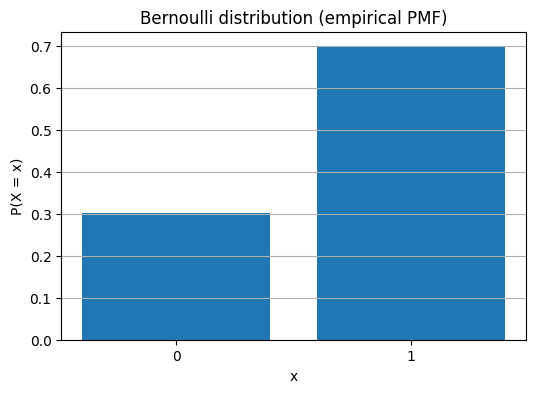

In [10]:
p = 0.7
sample = rng.binomial(n=1, p=p, size=1000)
values, counts = np.unique(sample, return_counts=True)

plt.figure(figsize=(6, 4))
plt.bar(values, counts / counts.sum())
plt.xticks([0, 1])
plt.title("Bernoulli distribution (empirical PMF)")
plt.xlabel("x")
plt.ylabel("P(X = x)")
plt.grid(True, axis="y")
plt.show()

## 9.2 Binomial Distribution

A **binomial random variable** counts the number of successes in $n$ independent Bernoulli trials.

$$
P(X=k)=\binom{n}{k}p^k(1-p)^{n-k}
$$

### Why this matters in ML

Binomial ideas appear in repeated binary outcomes and aggregated success counts.

### Common mistakes

- Forgetting independence assumptions.
- Confusing Bernoulli and binomial.

### ML takeaway

The binomial distribution extends Bernoulli from one trial to many repeated trials.

### Quick check

1. What does the binomial random variable count?  
2. How is binomial related to Bernoulli?  
3. What assumptions are important for a binomial model?

[Back to Topics](#topics-covered)

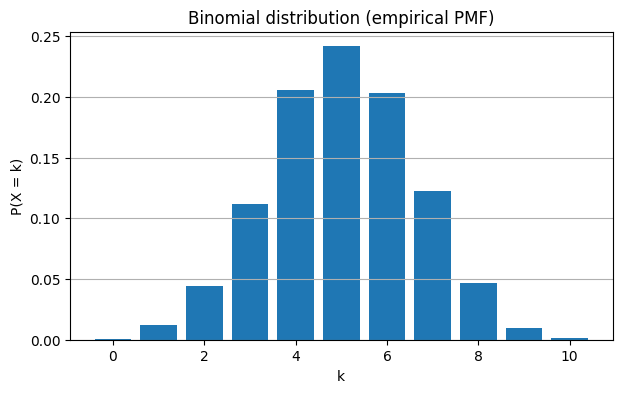

In [11]:
n = 10
p = 0.5
sample = rng.binomial(n=n, p=p, size=10000)
values, counts = np.unique(sample, return_counts=True)

plt.figure(figsize=(7, 4))
plt.bar(values, counts / counts.sum())
plt.title("Binomial distribution (empirical PMF)")
plt.xlabel("k")
plt.ylabel("P(X = k)")
plt.grid(True, axis="y")
plt.show()

## 9.3 Poisson Distribution

A **Poisson random variable** models the number of events in a fixed interval.

$$
P(X=k)=\frac{e^{-\lambda}\lambda^k}{k!}
$$

### Why this matters in ML

Poisson ideas are useful for count data and rare-event modeling.

### Common mistakes

- Forgetting that Poisson is for counts, not continuous measurements.

### ML takeaway

Poisson is a standard model for counts of events over time or space.

### Quick check

1. What kind of data is Poisson designed for?  
2. What does the parameter $\lambda$ represent?  
3. Why is Poisson useful for rare-event modeling?

[Back to Topics](#topics-covered)

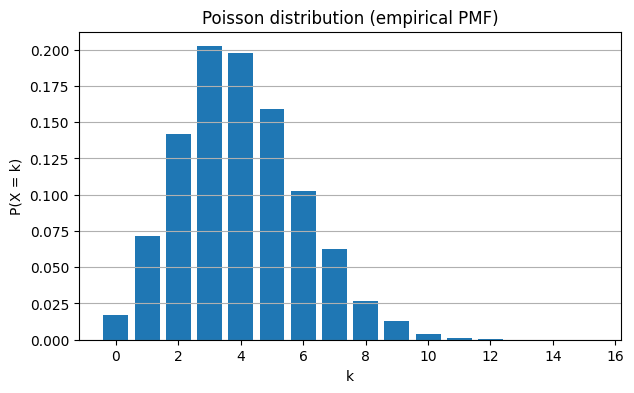

In [12]:
lam = 4.0
sample = rng.poisson(lam=lam, size=10000)
values, counts = np.unique(sample, return_counts=True)

plt.figure(figsize=(7, 4))
plt.bar(values, counts / counts.sum())
plt.title("Poisson distribution (empirical PMF)")
plt.xlabel("k")
plt.ylabel("P(X = k)")
plt.grid(True, axis="y")
plt.show()

<a id=10-distributions-for-continuous-random-variables></a>
# 10. Distributions for Continuous Random Variables

Continuous distributions are useful when the variable represents measurements, durations, or other quantities varying on a continuum.

## 10.1 Uniform Distribution

If $X \sim \text{Uniform}(a,b)$, then

$$
f(x)=\frac{1}{b-a}, \quad a \le x \le b
$$

### Why this matters in ML

Uniform distributions are useful in random initialization and simulation.

### ML takeaway

Uniform is the simplest continuous distribution with no preferred location.

### Quick check

1. What does “uniform” mean in this context?  
2. Why is uniform sampling common in simulation?  
3. Over what kind of interval is the density constant?

[Back to Topics](#topics-covered)

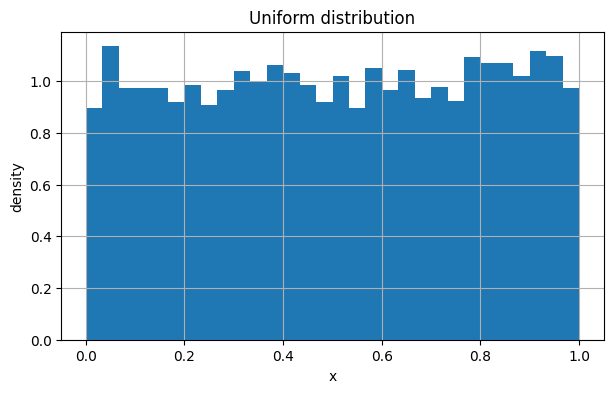

In [13]:
sample = rng.uniform(0, 1, size=5000)
plt.figure(figsize=(7, 4))
plt.hist(sample, bins=30, density=True)
plt.title("Uniform distribution")
plt.xlabel("x")
plt.ylabel("density")
plt.grid(True)
plt.show()

## 10.2 Exponential Distribution

If $X \sim \text{Exponential}(\lambda)$, then

$$
f(x)=\lambda e^{-\lambda x}, \quad x \ge 0
$$

### Why this matters in ML

Exponential ideas are useful in waiting-time modeling.

### ML takeaway

Exponential is a natural model for positive waiting times.

### Quick check

1. What kind of variable is often modeled by an exponential distribution?  
2. Why must the values be nonnegative?  
3. How is exponential related to event timing?

[Back to Topics](#topics-covered)

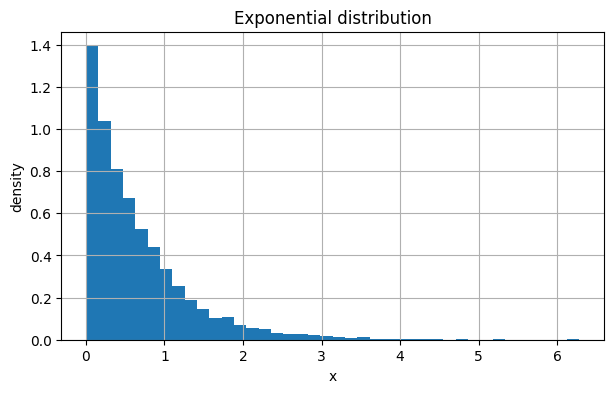

In [14]:
sample = rng.exponential(scale=1/1.5, size=5000)
plt.figure(figsize=(7, 4))
plt.hist(sample, bins=40, density=True)
plt.title("Exponential distribution")
plt.xlabel("x")
plt.ylabel("density")
plt.grid(True)
plt.show()

## 10.3 Normal Distribution

If $X \sim \mathcal{N}(\mu, \sigma^2)$, then

$$
f(x)=\frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)
$$

### Why this matters in ML

Normal distributions appear in noise models, errors, estimators, and approximations.

### ML takeaway

The normal distribution is central because many aggregate effects behave approximately Gaussian.

### Quick check

1. What do $\mu$ and $\sigma$ represent?  
2. Why is the normal distribution so important in ML and statistics?  
3. Does every feature need to follow a normal distribution?

[Back to Topics](#topics-covered)

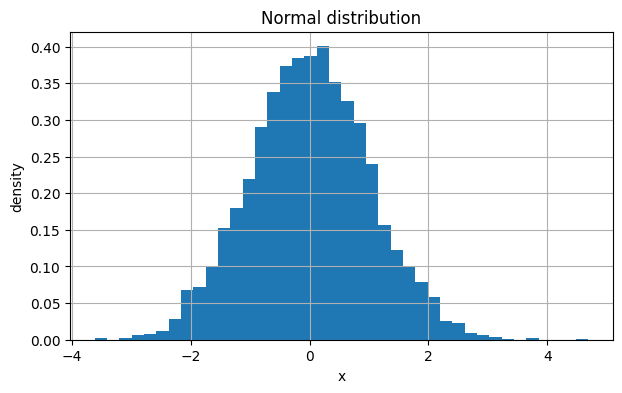

In [15]:
sample = rng.normal(loc=0, scale=1, size=5000)
plt.figure(figsize=(7, 4))
plt.hist(sample, bins=40, density=True)
plt.title("Normal distribution")
plt.xlabel("x")
plt.ylabel("density")
plt.grid(True)
plt.show()

<a id=11-central-limit-theorem></a>
# 11. Central Limit Theorem

The **Central Limit Theorem (CLT)** says that the distribution of the sample mean approaches a normal distribution as the sample size increases.

### Why this matters in ML

CLT explains why averages often look Gaussian and why normal approximations are common.

### ML takeaway

CLT explains why averaging often produces approximately normal behavior.

### Quick check

1. What becomes approximately normal under CLT?  
2. Does the original variable need to be normal?  
3. Why is CLT useful in statistics and ML?

[Back to Topics](#topics-covered)

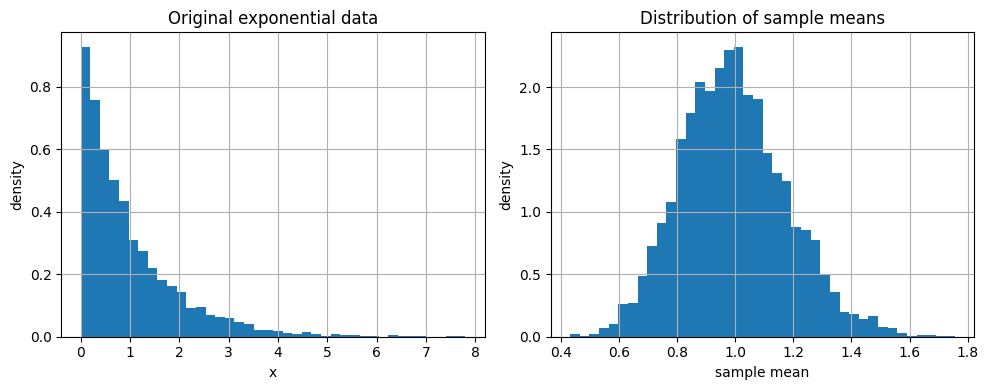

In [16]:
n_experiments = 5000
sample_size = 30
means = []

for _ in range(n_experiments):
    sample = rng.exponential(scale=1.0, size=sample_size)
    means.append(sample.mean())

means = np.array(means)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
orig = rng.exponential(scale=1.0, size=5000)
plt.hist(orig, bins=40, density=True)
plt.title("Original exponential data")
plt.xlabel("x")
plt.ylabel("density")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.hist(means, bins=40, density=True)
plt.title("Distribution of sample means")
plt.xlabel("sample mean")
plt.ylabel("density")
plt.grid(True)

plt.tight_layout()
plt.show()

<a id=12-law-of-large-numbers></a>
# 12. Law of Large Numbers

The **Law of Large Numbers (LLN)** says that as the number of observations grows, the sample average tends to approach the true expected value.

### Why this matters in ML

LLN justifies empirical averages and stable dataset-based estimation.

### ML takeaway

LLN explains why empirical averages become reliable with enough data.

### Quick check

1. What quantity converges under LLN?  
2. How is LLN different from CLT?  
3. Why is LLN important for data-driven estimation?

[Back to Topics](#topics-covered)

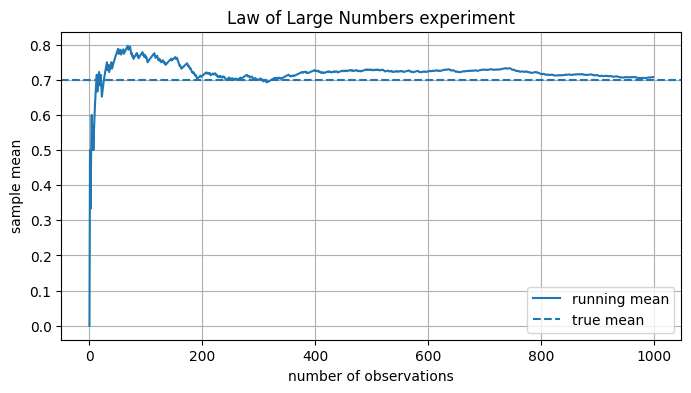

In [17]:
n = 1000
sample = rng.binomial(n=1, p=0.7, size=n)
running_mean = np.cumsum(sample) / np.arange(1, n + 1)

plt.figure(figsize=(8, 4))
plt.plot(running_mean, label="running mean")
plt.axhline(0.7, linestyle="--", label="true mean")
plt.title("Law of Large Numbers experiment")
plt.xlabel("number of observations")
plt.ylabel("sample mean")
plt.grid(True)
plt.legend()
plt.show()

<a id=3-characteristics-of-a-random-variable-skewness-and-kurtosis></a>
# 13. Characteristics of a Random Variable: Skewness and Kurtosis

### Skewness

Skewness measures asymmetry of a distribution.

### Kurtosis

Kurtosis measures how heavy the tails are and how concentrated the data is near the center.

### Why this matters in ML

These characteristics help with feature-shape analysis, transformations, and outlier awareness.

### ML takeaway

Skewness and kurtosis describe shape beyond mean and variance.

### Quick check

1. What does skewness measure?  
2. What does kurtosis help describe?  
3. Why might skewness matter before training a model?

[Back to Topics](#topics-covered)

In [18]:
def sample_skewness(x):
    x = np.asarray(x)
    m = x.mean()
    s = x.std(ddof=0)
    return np.mean(((x - m) / s) ** 3)

def sample_kurtosis(x):
    x = np.asarray(x)
    m = x.mean()
    s = x.std(ddof=0)
    return np.mean(((x - m) / s) ** 4)

normal_data = rng.normal(size=5000)
skewed_data = rng.exponential(size=5000)

print("Normal data skewness:", sample_skewness(normal_data))
print("Normal data kurtosis:", sample_kurtosis(normal_data))
print("Exponential data skewness:", sample_skewness(skewed_data))
print("Exponential data kurtosis:", sample_kurtosis(skewed_data))

Normal data skewness: 0.04169418555002536
Normal data kurtosis: 2.9169302366754084
Exponential data skewness: 2.0831246360501727
Exponential data kurtosis: 9.392177275837723


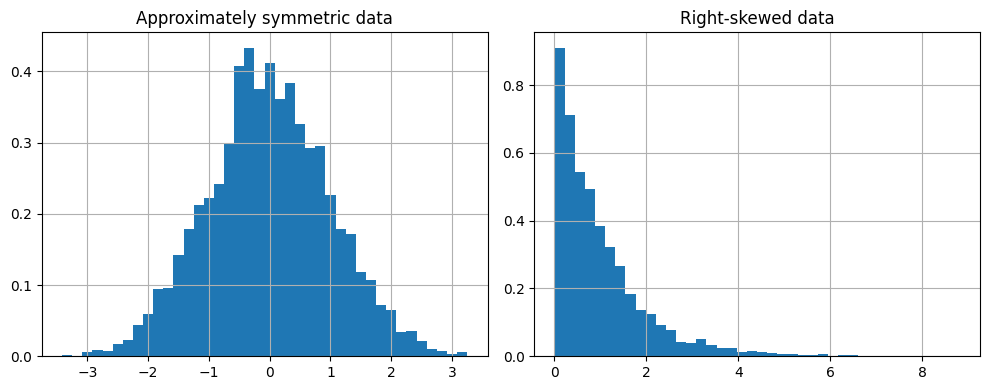

In [19]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(normal_data, bins=40, density=True)
plt.title("Approximately symmetric data")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.hist(skewed_data, bins=40, density=True)
plt.title("Right-skewed data")
plt.grid(True)

plt.tight_layout()
plt.show()

<a id=14-data-normalization></a>
# 14. Data Normalization

A common related transformation is **standardization**:

$$
z = \frac{x-\mu}{\sigma}
$$

### Why this matters in ML

Normalization or standardization often helps gradient-based optimization, numerical stability, and fair feature comparison.

### Common mistakes

- Thinking normalization automatically makes a variable normal.
- Confusing normalization with standardization.

### ML takeaway

Normalization is strongly connected to the statistical properties of variables.

### Quick check

1. What does standardization do to the mean and standard deviation?  
2. Does standardization make a variable normally distributed?  
3. Why does scaling help many ML algorithms?

[Back to Topics](#topics-covered)

Original mean: 49.94245388100191 Original std: 9.990136396028866
Standardized mean: 4.263256414560601e-17 Standardized std: 1.0


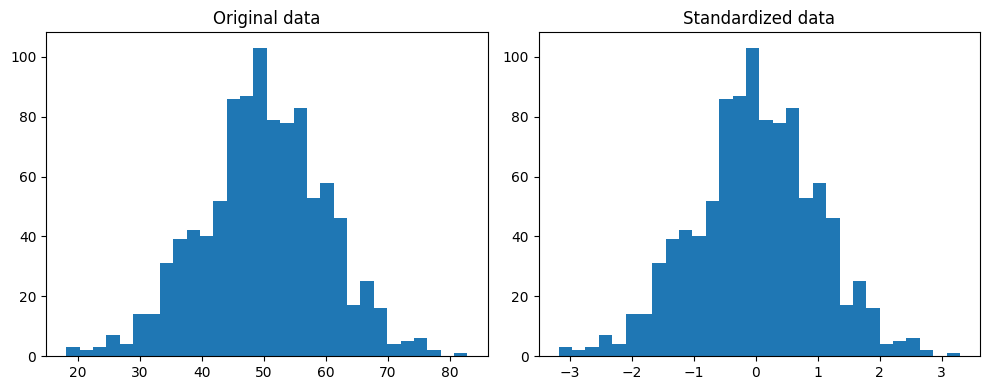

In [20]:
data = rng.normal(loc=50, scale=10, size=1000)
z = (data - data.mean()) / data.std()

print("Original mean:", data.mean(), "Original std:", data.std())
print("Standardized mean:", z.mean(), "Standardized std:", z.std())

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(data, bins=30)
plt.title("Original data")

plt.subplot(1, 2, 2)
plt.hist(z, bins=30)
plt.title("Standardized data")

plt.tight_layout()
plt.show()

<a id=15-bootstrapping></a>
# 15. Bootstrapping

**Bootstrapping** is a resampling method: we repeatedly sample **with replacement** from observed data and recompute a statistic.

### Why this matters in ML

Bootstrapping is useful for uncertainty estimation and confidence intervals.

### Common mistakes

- Forgetting that bootstrap sampling is with replacement.

### ML takeaway

Bootstrapping turns one dataset into many resampled versions for uncertainty analysis.

### Quick check

1. Does bootstrapping sample with or without replacement?  
2. Why is bootstrapping useful?  
3. What kind of uncertainty can it help estimate?

[Back to Topics](#topics-covered)

Original sample mean: 9.960507685144552
Bootstrap mean of means: 9.961178584119537
Approx. 95% interval: [ 9.6768 10.2455]


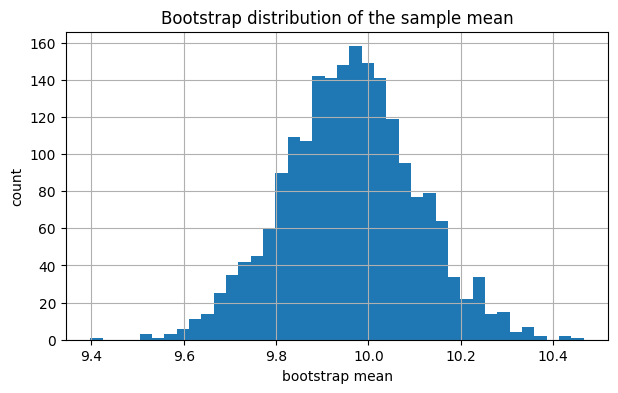

In [21]:
data = rng.normal(loc=10, scale=2, size=200)

bootstrap_means = []
for _ in range(2000):
    sample = rng.choice(data, size=len(data), replace=True)
    bootstrap_means.append(sample.mean())

bootstrap_means = np.array(bootstrap_means)

print("Original sample mean:", data.mean())
print("Bootstrap mean of means:", bootstrap_means.mean())
print("Approx. 95% interval:", np.percentile(bootstrap_means, [2.5, 97.5]))

plt.figure(figsize=(7, 4))
plt.hist(bootstrap_means, bins=40)
plt.title("Bootstrap distribution of the sample mean")
plt.xlabel("bootstrap mean")
plt.ylabel("count")
plt.grid(True)
plt.show()

<a id=16-box-plot-and-iqr></a>
# 16. Box Plot and IQR

A **box plot** summarizes a distribution using quartiles.

The interquartile range is

$$
IQR = Q_3 - Q_1
$$

A common outlier rule uses:

- lower bound: $Q_1 - 1.5 \cdot IQR$
- upper bound: $Q_3 + 1.5 \cdot IQR$

### Why this matters in ML

Box plots and IQR are useful for robust summaries and outlier detection.

### Common mistakes

- Treating every flagged point as a true anomaly without context.

### ML takeaway

Box plots and IQR give a compact and robust summary of spread and outliers.

### Quick check

1. What does IQR measure?  
2. Why is IQR considered robust?  
3. How are box plots useful in exploratory data analysis?

[Back to Topics](#topics-covered)

Q1: -0.6578954932732913
Q3: 0.6017049274112145
IQR: 1.2596004206845057
Lower bound: -2.54729612430005
Upper bound: 2.4911055584379733


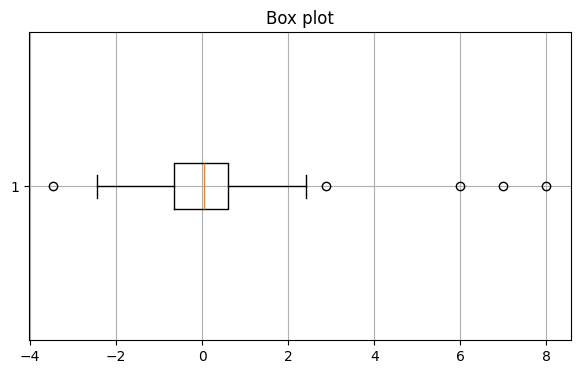

In [22]:
data = np.concatenate([rng.normal(0, 1, 500), np.array([6, 7, 8])])

q1 = np.percentile(data, 25)
q3 = np.percentile(data, 75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower bound:", lower)
print("Upper bound:", upper)

plt.figure(figsize=(7, 4))
plt.boxplot(data, vert=False)
plt.title("Box plot")
plt.grid(True)
plt.show()


# Cheat Sheet

### Event complement

$$
P(A^c)=1-P(A)
$$

### Union rule

$$
P(A \cup B)=P(A)+P(B)-P(A \cap B)
$$

### Conditional probability

$$
P(A \mid B)=\frac{P(A \cap B)}{P(B)}
$$

### Bayes' theorem

$$
P(A \mid B)=\frac{P(B \mid A)P(A)}{P(B)}
$$

### PMF

For discrete $X$:

$$
P(X=x)
$$

### PDF

For continuous $X$:

$$
f(x)
$$

### CDF

$$
F(x)=P(X \le x)
$$

### Bernoulli

$$
P(X=1)=p,\quad P(X=0)=1-p
$$

### Binomial

$$
P(X=k)=\binom{n}{k}p^k(1-p)^{n-k}
$$

### Poisson

$$
P(X=k)=\frac{e^{-\lambda}\lambda^k}{k!}
$$

### Uniform density

$$
f(x)=\frac{1}{b-a}
$$

### Exponential density

$$
f(x)=\lambda e^{-\lambda x}, \quad x \ge 0
$$

### Normal density

$$
f(x)=\frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)
$$

## Standardization

$$
z=\frac{x-\mu}{\sigma}
$$

### IQR

$$
IQR = Q_3 - Q_1
$$

#### [Math for ML. Part 1. Basics of Linear algebra & analytic geometry](https://www.kaggle.com/code/kupershtein/math-for-ml-part-1-lin-algebra-an-geometry)

#### [Math for ML - Part 2. Basics of calculus (MatAn)](https://www.kaggle.com/code/kupershtein/math-for-ml-part-2-basics-of-calculus-matan)

#### [Math for ML - Part 4. Basics of mathematical statistics](https://www.kaggle.com/code/kupershtein/math-for-ml-part-4-basics-of-math-statistics)


## **I hope it useful for you! Thanks for upvote!**¶